<a href="https://colab.research.google.com/github/sandrega/ModelosAnaliticosUnicafam202607/blob/main/Parcialfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PARCIAL FINAL **

ESTUDIANTES:

JENIFFER LEON

SAUL ANDRES GARCIA




In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_excel("/content/sample_data/crime_data (1).xlsx")

In [3]:
dataset

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


In [4]:
# Paso 4. Seleccionar las variables

X = dataset.iloc[:, 1:].values

In [5]:
X

array([[ 13.2, 236. ,  58. ,  21.2],
       [ 10. , 263. ,  48. ,  44.5],
       [  8.1, 294. ,  80. ,  31. ],
       [  8.8, 190. ,  50. ,  19.5],
       [  9. , 276. ,  91. ,  40.6],
       [  7.9, 204. ,  78. ,  38.7],
       [  3.3, 110. ,  77. ,  11.1],
       [  5.9, 238. ,  72. ,  15.8],
       [ 15.4, 335. ,  80. ,  31.9],
       [ 17.4, 211. ,  60. ,  25.8],
       [  5.3,  46. ,  83. ,  20.2],
       [  2.6, 120. ,  54. ,  14.2],
       [ 10.4, 249. ,  83. ,  24. ],
       [  7.2, 113. ,  65. ,  21. ],
       [  2.2,  56. ,  57. ,  11.3],
       [  6. , 115. ,  66. ,  18. ],
       [  9.7, 109. ,  52. ,  16.3],
       [ 15.4, 249. ,  66. ,  22.2],
       [  2.1,  83. ,  51. ,   7.8],
       [ 11.3, 300. ,  67. ,  27.8],
       [  4.4, 149. ,  85. ,  16.3],
       [ 12.1, 255. ,  74. ,  35.1],
       [  2.7,  72. ,  66. ,  14.9],
       [ 16.1, 259. ,  44. ,  17.1],
       [  9. , 178. ,  70. ,  28.2],
       [  6. , 109. ,  53. ,  16.4],
       [  4.3, 102. ,  62. ,  16.5],
 

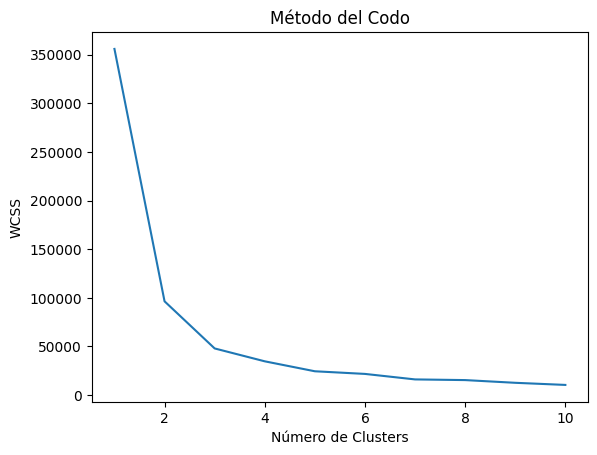

In [6]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
# Paso 6. Entrenamiento del modelo

kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)

y_kmeans = kmeans.fit_predict(X)

In [8]:
# Paso 7. Agregar el cluster al dataset

dataset["Cluster"] = y_kmeans

dataset

,Unnamed: 0,Murder,Assault,UrbanPop,Rape,Cluster
0,Alabama,13.2,236,58,21.2,1
1,Alaska,10.0,263,48,44.5,1
2,Arizona,8.1,294,80,31.0,1
3,Arkansas,8.8,190,50,19.5,2
4,California,9.0,276,91,40.6,1
5,Colorado,7.9,204,78,38.7,2
6,Connecticut,3.3,110,77,11.1,0
7,Delaware,5.9,238,72,15.8,1
8,Florida,15.4,335,80,31.9,1
9,Georgia,17.4,211,60,25.8,2


In [9]:
# Resumen por cluster

dataset.groupby("Cluster").mean(numeric_only=True)

,Murder,Assault,UrbanPop,Rape
Cluster,,,,
0,4.270000,87.550000,59.750000,14.390000
1,11.812500,272.562500,68.312500,28.375000
2,8.214286,173.285714,70.642857,22.842857


In [10]:
dataset.groupby("Cluster").mean(numeric_only=True)

,Murder,Assault,UrbanPop,Rape
Cluster,,,,
0,4.270000,87.550000,59.750000,14.390000
1,11.812500,272.562500,68.312500,28.375000
2,8.214286,173.285714,70.642857,22.842857


In [11]:
print("1. ¿Cómo podemos agrupar los estados?")
print("Los estados se agrupan en 3 clusters:")
print("- Cluster 0: Baja criminalidad.")
print("- Cluster 1: Alta criminalidad.")
print("- Cluster 2: Criminalidad media.")

1. ¿Cómo podemos agrupar los estados?
Los estados se agrupan en 3 clusters:
- Cluster 0: Baja criminalidad.
- Cluster 1: Alta criminalidad.
- Cluster 2: Criminalidad media.


In [12]:
print("2. ¿Cuáles son los estados con necesidad de profesionales con mayor capacidad?")
print("Los estados del Cluster 1 presentan los mayores niveles de criminalidad.")
print("Promedios:")
print("Murder: 11.81")
print("Assault: 272.56")
print("Rape: 28.38")

2. ¿Cuáles son los estados con necesidad de profesionales con mayor capacidad?
Los estados del Cluster 1 presentan los mayores niveles de criminalidad.
Promedios:
Murder: 11.81
Assault: 272.56
Rape: 28.38


In [13]:
print("3. ¿Cómo distribuiría los recursos?")
print("Cluster 1: Policías especializados.")
print("Cluster 2: Policías de patrullaje.")
print("Cluster 0: Cadetes y prevención.")

3. ¿Cómo distribuiría los recursos?
Cluster 1: Policías especializados.
Cluster 2: Policías de patrullaje.
Cluster 0: Cadetes y prevención.


In [14]:
print("4. ¿Cuáles son los grupos que existen?")
print("Grupo 1: Baja criminalidad.")
print("Grupo 2: Criminalidad media.")
print("Grupo 3: Alta criminalidad.")

4. ¿Cuáles son los grupos que existen?
Grupo 1: Baja criminalidad.
Grupo 2: Criminalidad media.
Grupo 3: Alta criminalidad.


In [15]:
print("5. Recomendaciones finales")
print("- Priorizar recursos para el Cluster 1.")
print("- Mantener vigilancia en el Cluster 2.")
print("- Fortalecer prevención en el Cluster 0.")
print("- Actualizar periódicamente el modelo K-Means.")

5. Recomendaciones finales
- Priorizar recursos para el Cluster 1.
- Mantener vigilancia en el Cluster 2.
- Fortalecer prevención en el Cluster 0.
- Actualizar periódicamente el modelo K-Means.
